In [1]:
import netrd
import networkx as nx
import random
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import adjusted_mutual_info_score
import seaborn as sns
from itertools import combinations
import math
import pandas as pd
from collections import defaultdict

# monkey patch numpy to support old netrd code
if not hasattr(np, 'float'):
    np.float = float # ty: ignore

q1 - Network Reconstruction

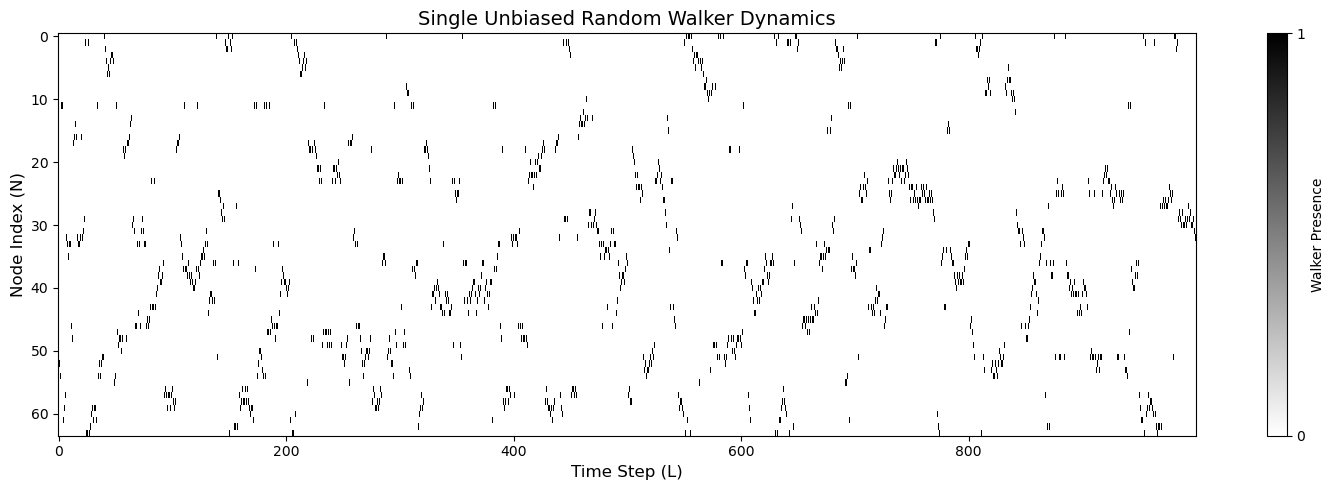

In [2]:
G = nx.watts_strogatz_graph(64, 4, .25)

# --- run sim ---

model = netrd.dynamics.SingleUnbiasedRandomWalker()
sim_results = {}
available = list(G.nodes())
for i in range(20):
    seed = random.choice(available)
    tseries = model.simulate(G, 1000, seed)
    H = model.results['ground_truth']
    sim_results[seed] = (tseries, H)
    available.remove(seed)

# --- visualize 1st time-series matrix ---

# retrieve 1st element from 1st tuple
mat_to_show = next(iter(sim_results.values()))[0]

# plot
plt.figure(figsize=(15, 5))
plt.imshow(mat_to_show, 
           aspect='auto',
           cmap='binary',
           interpolation='none')

# aesthetics
plt.colorbar(label='Walker Presence', ticks=[0, 1])
plt.title('Single Unbiased Random Walker Dynamics', fontsize=14)
plt.xlabel('Time Step (L)', fontsize=12)
plt.ylabel('Node Index (N)', fontsize=12)

plt.tight_layout()
#plt.savefig('imgs/randwalk_timeseries.png')

In [27]:
# --- reconstruction ---

recon = netrd.reconstruction.GrangerCausality()

# loop
recon_results = {}
for seed, (tseries, H) in sim_results.items():
    G_recon = recon.fit(tseries)
    recon_results[seed] = (G_recon, H)

# custom threshold version
recon_results_thr = {}
for seed, (tseries, H) in sim_results.items():
    G_recon = recon.fit(tseries, threshold_type='degree', avg_k=4)
    recon_results_thr[seed] = (G_recon, H)

c:\Users\User\anaconda3\envs\school\lib\site-packages\netrd\utilities\threshold.py:40: RuntimeWarning: Setting 'cutoffs' argument is strongly encouraged. Using cutoff range of (-1, 1).
  warnings.warn(
c:\Users\User\anaconda3\envs\school\lib\site-packages\netrd\utilities\threshold.py:40: RuntimeWarning: Setting 'cutoffs' argument is strongly encouraged. Using cutoff range of (-1, 1).
  warnings.warn(
c:\Users\User\anaconda3\envs\school\lib\site-packages\netrd\utilities\threshold.py:40: RuntimeWarning: Setting 'cutoffs' argument is strongly encouraged. Using cutoff range of (-1, 1).
  warnings.warn(
c:\Users\User\anaconda3\envs\school\lib\site-packages\netrd\utilities\threshold.py:40: RuntimeWarning: Setting 'cutoffs' argument is strongly encouraged. Using cutoff range of (-1, 1).
  warnings.warn(
c:\Users\User\anaconda3\envs\school\lib\site-packages\netrd\utilities\threshold.py:40: RuntimeWarning: Setting 'cutoffs' argument is strongly encouraged. Using cutoff range of (-1, 1).
  warni

C:\Users\User\AppData\Local\Temp\ipykernel_2364\1587449824.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seeds,


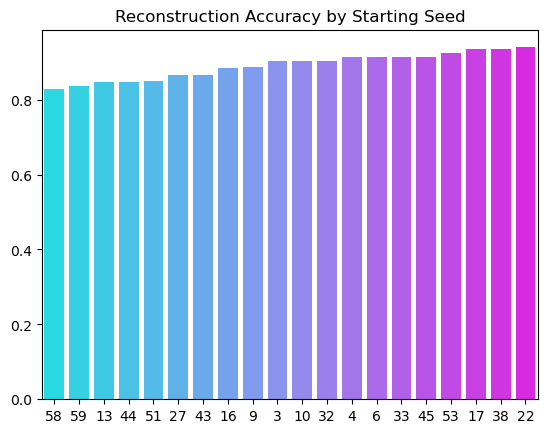

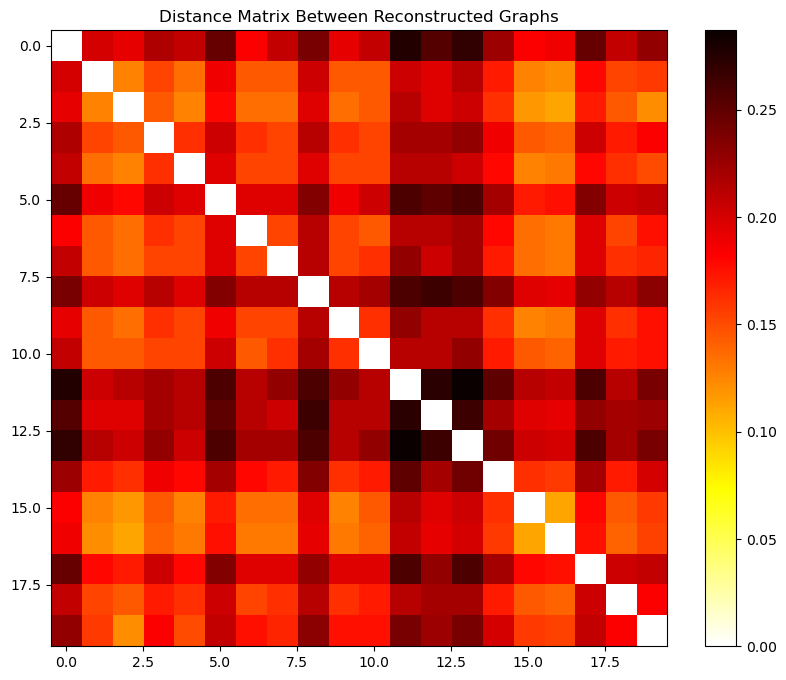

In [ ]:
# --- evaluation (d-f) ---

# AMI function for graph similarity
def graph_ami(G1, G2):
    # converting to matrices and flattening for function
    adj1 = nx.to_numpy_array(G1).flatten()
    adj2 = nx.to_numpy_array(G2).flatten()

    # binarize both matrices (float -> bool -> int)
    adj1 = (adj1 > 0).astype(int)
    adj2 = (adj2 > 0).astype(int)

    return adjusted_mutual_info_score(adj1, adj2)

# create comparison list of G/R tuples and evaluate
comparison_pairs = list(recon_results_thr.values())
seeds=list(recon_results_thr.keys())
scores = []
for R, G in comparison_pairs:
    score = graph_ami(R, G)
    scores.append(score)

# plotting
ordering = [label for _, label in sorted(zip(scores, seeds))]
sns.barplot(x=seeds,
            y=scores,
            palette='cool',
            order=ordering)
plt.title('Reconstruction Accuracy by Starting Seed')
plt.savefig('imgs/reconstruction_performance_barplot.png')
plt.show()

# --- R-R pairs (part e) ---

Rs = [pair[0] for pair in comparison_pairs]

# init matrix
n = len(Rs)
dist_mat = np.zeros((n,n))

r_pairs = list(combinations(range(n), 2))
for r1, r2 in r_pairs:
    score = graph_ami(Rs[r1], Rs[r2])
    dist = 1 - score
    # fill matrix on both sides
    dist_mat[r1, r2] = dist
    dist_mat[r2, r1] = dist

# plotting
plt.figure(figsize=(10, 8))
plt.imshow(dist_mat, cmap='hot_r') # reversed for distance
plt.colorbar()
plt.title("Distance Matrix Between Reconstructed Graphs")
plt.savefig('imgs/reconstructed_comb_heatmap.png')
plt.show()

q2 - Big Data

Testing for epsilon = 0.01...
Testing for epsilon = 0.05...
Testing for epsilon = 0.1...


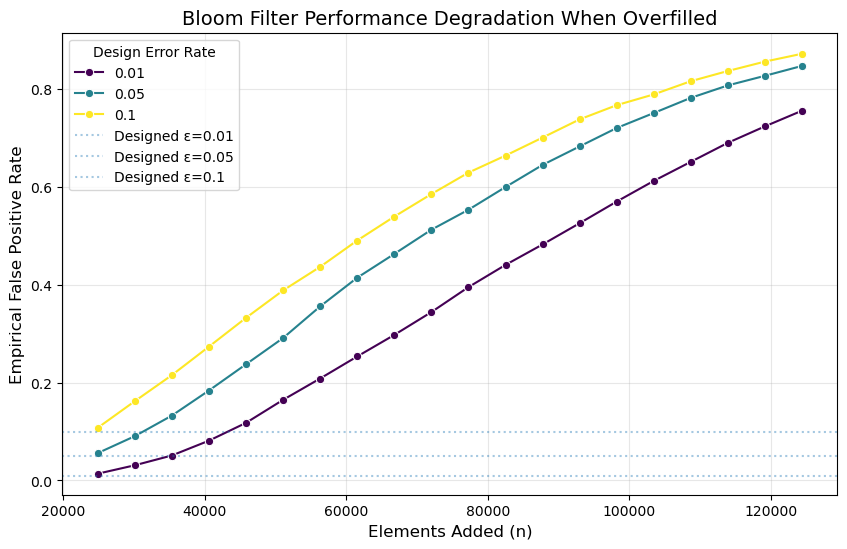

<Figure size 640x480 with 0 Axes>

In [ ]:
# --- create bloom filter ---

def bloomFilter(n, err):
    ''' 
    Initializes an empty bloom filter with desired parameters.
    '''
    # formulas for m and k
    k = int(-(math.log2(err)))
    m = int(-(n*math.log(err)) / (math.log(2))**2)

    return np.zeros(m, dtype=int), k

# single hash function repeated with slight variations of the edge (extra "index" element
# added to tuple) in an order that remains consistent while adding/looking up (same as notebook)
def bloomHash(edge, i):
    return hash(tuple([i, *edge])) # concise tuple -> list -> tuple conversion

def add_to_bloom(edges, filter_arr, k):
    ''' 
    Adds a set of edges to an empty bloom filter.
    '''
    m = len(filter_arr) # m is the size of the filter
    
    for edge in edges:
        for i in range(k): # run k times
            # modulo operation to wrap the massive number into one of m index slots
            bin_ = bloomHash(edge, i) % m
            filter_arr[bin_] = 1 # set indices to 1

    return filter_arr

def lookup_bloom(elem, filter, k):
    ''' 
    Checks bloom filter for specified edge.
    '''
    m = len(filter)
    for i in range(k):
        bin_ = bloomHash(elem, i) % m
        if filter[bin_] == 0:
            return False 
    return True

# --- test ---

# init graph
G = nx.erdos_renyi_graph(1000, 0.05)

# separate true edges from known non-edges
true_edges = list(G.edges())
non_edges = list(nx.non_edges(G))
random.shuffle(non_edges) # shuffle so i can pull random samples

edgenum = len(true_edges)

test_errs = [0.01, 0.05, 0.1]

# create range of specified size using linspace and round values to nearest int
test_ns = np.rint(np.linspace(edgenum, edgenum*5, 20)).astype(int)

# use 5,000 non-edges to test empirical false positive rate
probe_sample_size = 5000 

# ensure probe set is completely isolated
max_extra_needed = max(test_ns) - edgenum
probe_set = non_edges[max_extra_needed : max_extra_needed + probe_sample_size]

# start trials
performances = []
for err in test_errs:
    print(f"Testing for epsilon = {err}...")
    
    for n in test_ns:
        emptyfilt, k = bloomFilter(edgenum, err)
        
        # test overfilling by adding up to n
        extra_edges_needed = n - edgenum
        edges_to_add = true_edges + non_edges[:extra_edges_needed]
        filt = add_to_bloom(edges_to_add, emptyfilt, k)
        
        # probe with the isolated non-edges to find empirical fp rate
        false_positives = sum(1 for e in probe_set if lookup_bloom(e, filt, k))
        empirical_fp = false_positives / probe_sample_size
        
        performances.append({
            'err': err,
            'n': n,
            'empirical_fp': empirical_fp,
        })

# --- plotting ---

df = pd.DataFrame(performances)

plt.figure(figsize=(10, 6))
sns.lineplot(data=df, 
             x='n', 
             y='empirical_fp', 
             hue='err',
             marker='o',
             palette='viridis')

# reference lines for designed rates
for err in test_errs:
    plt.axhline(y=err, linestyle=':', alpha=0.4, 
                label=f'Designed ε={err}')

plt.title('Bloom Filter Performance Degradation When Overfilled', fontsize=14)
plt.xlabel(f'Elements Added (n)', fontsize=12)
plt.ylabel('Empirical False Positive Rate', fontsize=12)
plt.legend(title='Design Error Rate')
plt.grid(True, alpha=0.3)
plt.show()

plt.savefig('imgs/bloom_fp.png')

q3 - ABM

In [ ]:
# --- NK generator function ---

def generate_nk_landscape(N=20, K=5, seed=None, apply_paper_skew=True):
    """
    Create one NK landscape and return a fitness function on binary strings.
    This is the "environment" or "problem space" that agents search over.
    It does NOT implement the agent-based model itself. It only defines
    how good or bad each binary-string solution is.

    This function:
    1. builds the local dependency structure,
    2. creates random contribution tables,
    3. computes the score of every possible bitstring,
    4. normalizes by the exact global maximum,
    5. optionally applies the paper-style r^8 transformation.

    --------------------------------------------------------------------
    PARAMETERS
    --------------------------------------------------------------------
    N : int
    Length of the bitstring.
    K : int
    Number of partner loci that affect each locus.
    Must satisfy K < N.
    seed : int or None
    Random seed for reproducibility.
    apply_paper_skew : bool
    If True, apply the paper's monotonic r^8 transformation after
    normalization by the global maximum.
    --------------------------------------------------------------------
    RETURNS
    --------------------------------------------------------------------
    landscape : dict
    Contains:
    - "fitness_fn": callable that scores a bitstring
    - "N", "K"
    - "partners": dependency structure
    - "tables": local NK contribution tables
    - "raw_scores": raw NK scores over all 2^N states
    - "normalized_scores": raw_scores / max(raw_scores)
    - "scores": final scores after optional r^8 transform
    - "global_max_raw": exact maximum raw score
    - "global_best_bits": one bitstring attaining the max
    --------------------------------------------------------------------
    COMPUTATIONAL NOTE
    --------------------------------------------------------------------
    This version explicitly enumerates all 2^N states.
    8
    That is feasible for N = 20:
    2^20 = 1,048,576 states
    That is one reason N = 20 is still manageable here.
    """
    if K >= N:
        raise ValueError("K must be less than N.")
    rng = np.random.default_rng(seed)
    def bits_to_int(bits):
        """
        Convert a bitstring into an integer index.
        Example:
        (0,0,0) -> 0
        (0,0,1) -> 1
        (0,1,0) -> 2
        ...
        """
        x = 0
        for b in bits:
            x = (x << 1) | int(b)
        return x
    def int_to_bits(x, N):
        """
        Convert an integer back into an N-bit tuple.
        """
        return tuple((x >> shift) & 1 for shift in range(N - 1, -1, -1))
    # ------------------------------------------------------------
    # Step 1: choose K partner loci for each locus i
    # ------------------------------------------------------------
    partners = []
    for i in range(N):
        others = [j for j in range(N) if j != i]
        chosen = tuple(rng.choice(others, size=K, replace=False))
        partners.append(chosen)
    # ------------------------------------------------------------
    # Step 2: create random local contribution tables
    # Each locus gets a table with 2^(K+1) entries
    # ------------------------------------------------------------
    tables = []
    for i in range(N):
        table = rng.random(2 ** (K + 1))
        tables.append(table)
    # ------------------------------------------------------------
    # Step 3: enumerate all 2^N possible solutions
    # ------------------------------------------------------------
    num_states = 2 ** N
    states = np.arange(num_states, dtype=np.uint32)[:, None]
    shifts = np.arange(N - 1, -1, -1, dtype=np.uint32)
    bit_matrix = ((states >> shifts) & 1).astype(np.uint8)
    9
    # ------------------------------------------------------------
    # Step 4: compute raw NK score for every state
    # ------------------------------------------------------------
    raw_scores = np.zeros(num_states, dtype=np.float64)
    for i in range(N):
        # The local contribution for locus i depends on:
        # - bit i itself
        # - the K partner bits chosen for i
        idxs = (i,) + partners[i]
        local_bits = bit_matrix[:, idxs]
        # Convert each local bit-pattern into an integer lookup index
        local_powers = (1 << np.arange(K, -1, -1)).astype(np.uint32)
        table_indices = (local_bits * local_powers).sum(axis=1)
        raw_scores += tables[i][table_indices]
        raw_scores /= N
    # ------------------------------------------------------------
    # Step 5: normalize by the exact global maximum
    # ------------------------------------------------------------
    global_max_raw = float(raw_scores.max())
    normalized_scores = raw_scores / global_max_raw
    # ------------------------------------------------------------
    # Step 6: optional paper-style skew transformation
    # ------------------------------------------------------------
    if apply_paper_skew:
        scores = normalized_scores ** 8
    else:
        scores = normalized_scores.copy()
    argmax_state = int(raw_scores.argmax())
    global_best_bits = int_to_bits(argmax_state, N)
    def fitness_fn(bits):
        """
        Return the final fitness score of one bitstring.
        """
        idx = bits_to_int(bits)
        return float(scores[idx])
    return {
    "fitness_fn": fitness_fn,
    "N": N,
    "K": K,
    "partners": partners,
    "tables": tables,
    "raw_scores": raw_scores,
    "normalized_scores": normalized_scores,
    "scores": scores,
    "global_max_raw": global_max_raw,
    "global_best_bits": global_best_bits,
    }

# --- couldn't find mutation function so just made my own ---

def mutate(bits):
    pos = random.randint(0, len(bits) - 1)
    mutated = list(bits)
    mutated[pos] = 1 - mutated[pos]
    return tuple(mutated)

In [ ]:
# --- building out simulation ---

def apply_update(G):
    ''' 
    Implements base update rule: copy best neighbor fitness or else try mutation.
    '''
    result = {}
    for node in G.nodes():
        max_n_fitness = max([n['fitness'] for n in G.neighbors(node)])
        if node['fitness'] < max_n_fitness:
            node['fitness'] == max_n_fitness
        else:
            node['solution'] == mutate(node['solution'])
    result.update(G.nodes(data=True))

def run_sim(T, size, N, K, seed, apply_paper_skew=True):
    ''' 
    Runs simulation for Lazer-Friedman ABM on path graph and complete graph.
    Returns results for both in the form of a tuple containing a list of attribute
    dictionaries, indexed at 0 for path and 1 for complete.
    '''
    # get landscape + fitness fn
    landscape = generate_nk_landscape(N, K, seed=None, apply_paper_skew=apply_paper_skew)
    fitness_fn = landscape['fitness_fn']

    # --- init population ---

    # create test graphs
    G_path = nx.path_graph(size)
    G_complete = nx.complete_graph(size)

    # assign attrs
    attrs = {
        node: {
            'solution': random.getrandbits(N),
            'fitness': fitness_fn(node['solution'])
        }
        for node in G.nodes()
    }

    # apply to all nodes at once for both graphs
    nx.set_node_attributes(G_path, attrs)
    nx.set_node_attributes(G_complete, attrs)

    # --- apply synchronous update for T steps ---

    def sync_update(G):
        G_copy = G.copy()
        history = [{G_copy.nodes(data=True)}]
        for _ in range(T):
            history.append(apply_update(G_copy))
        return history

    hist_path = sync_update(G_path)
    hist_complete = sync_update(G_complete)

    return hist_path, hist_complete

1. landscape
2. initial pop
3. one update step
4. many update steps
5. repeated replicates
6. interpretation